In [ ]:
%load_ext autoreload
%autoreload 2

# 参考模型

- Llama3 系列
    - Llama-3.1-8b (130k)、Llama-3-8b-1M (1048k)
    - GQA
    - 32 Layers、8 KVHeads、32 Attention Heads (32/8=4 query groups)

# 收集指标

- **Key、Value** Tensor per **Layer** per **Group** per **Head**
    - w、w/o RoPE
- Attention Score per **Head** per **Layer**
- **Query** Tensor during **decoding**


In [ ]:
from transformers import AutoConfig

llama3_path = "/home/yexuming/.cache/modelscope/hub/models/LLM-Research/Meta-Llama-3___1-8B"
llama3_cfg = AutoConfig.from_pretrained(llama3_path)
llama3_cfg

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": 128001,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_type": "llama3"
  },
  "rope_theta": 500000.0,
  "tie_word_embeddings": false,
  "transformers_version": "4.57.1",
  "use_cache": true,
  "vocab_size": 128256
}

In [5]:
from transformers import AutoModelForCausalLM
llama3_model = AutoModelForCausalLM.from_pretrained(llama3_path)
llama3_model

Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.64it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

# AIME2024 工作负载

## 生成并保存注意力相关状态

> run aime_sweep.py first to generate tensor files

In [7]:
!python aime_sweep.py

Loading checkpoint shards: 100%|██████████████████| 4/4 [00:00<00:00,  4.26it/s]
[llama3_hook] qkvaQK capture is enabled. Saving to: results
Sample: 
{'ID': '2024-I-1', 'Problem': 'Every morning Aya goes for a $9$-kilometer-long walk and stops at a coffee shop afterwards. When she walks at a constant speed of $s$ kilometers per hour, the walk takes her 4 hours, including $t$ minutes spent in the coffee shop. When she walks $s+2$ kilometers per hour, the walk takes her 2 hours and 24 minutes, including $t$ minutes spent in the coffee shop. Suppose Aya walks at $s+\x0crac{1}{2}$ kilometers per hour. Find the number of minutes the walk takes her, including the $t$ minutes spent in the coffee shop.', 'Solution': '$\\frac{9}{s} + t = 4$ in hours and $\\frac{9}{s+2} + t = 2.4$ in hours. Subtracting the second equation from the first, we get, $\\frac{9}{s} - \\frac{9}{s+2} = 1.6$. Multiplying by $(s)(s+2)$, we get $9s+18-9s=18=1.6s^{2} + 3.2s$. Multiplying by 5/2 on both sides, we get $0 = 4s

In [1]:
from llm_study.utils import feature as ft

# print parameters which are saved in ./results
print(ft.stat("./results"))

{'layers': 31, 'steps': 128, 'types': ['attn_weights', 'key', 'key_RoPE', 'query', 'query_RoPE', 'value']}


## 不同 Head、Layer、Group 下注意力模式比较

(1, 32, 138, 138)


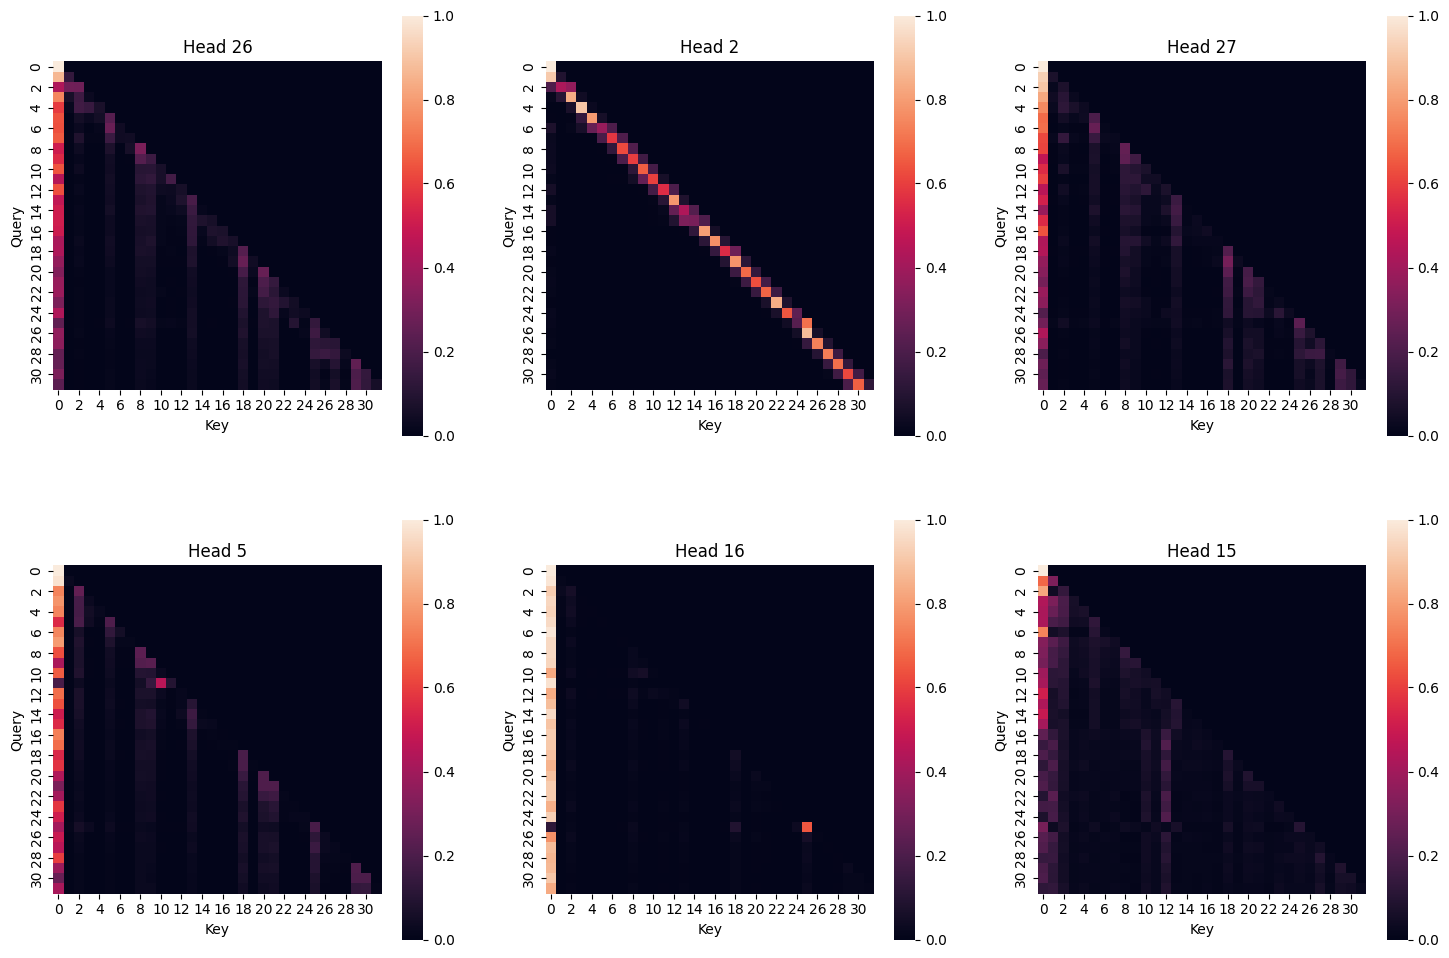

In [ ]:
from llm_study.utils import feature as ft
attn_weights = ft.load("./results", layer=0, step=1, type="attn_weights", format="numpy")
print(attn_weights.shape) # (batch, head, q, k)

from matplotlib import pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

from random import sample
from seaborn import heatmap
for i, h in enumerate(sample(range(32), 6)):
    x = i % 3
    y = i // 3
    axes = ax[y, x]
    heatmap(attn_weights[0, h, :32, :32], ax=axes, square=True, cbar=True)
    axes.set_title(f"Head {h}")
    axes.set_xlabel("Key")
    axes.set_ylabel("Query")
    
plt.show()

- 不同 Head 的注意力模式差异较大，难以从单个 Head 的注意力模式推断整体注意力模式。
- 大多数注意力模式体现了 attention sink 和 local 模式。
- 在上一个 Query 下得分高的 Token 有概率在下一个 Query 内依然得分高，体现了注意力得分的跨 Query 相似性。

In [ ]:
def gqa_heatmap(layer=0, group=0, q_head=0, step=1, grp_size=4, path="./results", end=-1, ax=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import llm_study.utils.feature as ft
    fig = None
    if ax is None:
        fig, ax = plt.subplots()

    q_head = group * grp_size + q_head
    attn_weights = ft.load(path, layer=layer, step=step, type="attn_weights", format="numpy")
    attn_weights = attn_weights[0, q_head]
    if end != -1:
        attn_weights = attn_weights[:end, :end]
    sns.heatmap(attn_weights, square=True, ax=ax)
    ax.set_title(f"Layer {layer}, Group {group}, Head {q_head}, Step {step}")
    ax.set_ylabel("Query")
    ax.set_xlabel("Key")
    if fig:
        fig.show()

随机选择的 Layer: 19
随机选择的 Heads: [8, 1, 9]
Head 8
Head 1
Head 9


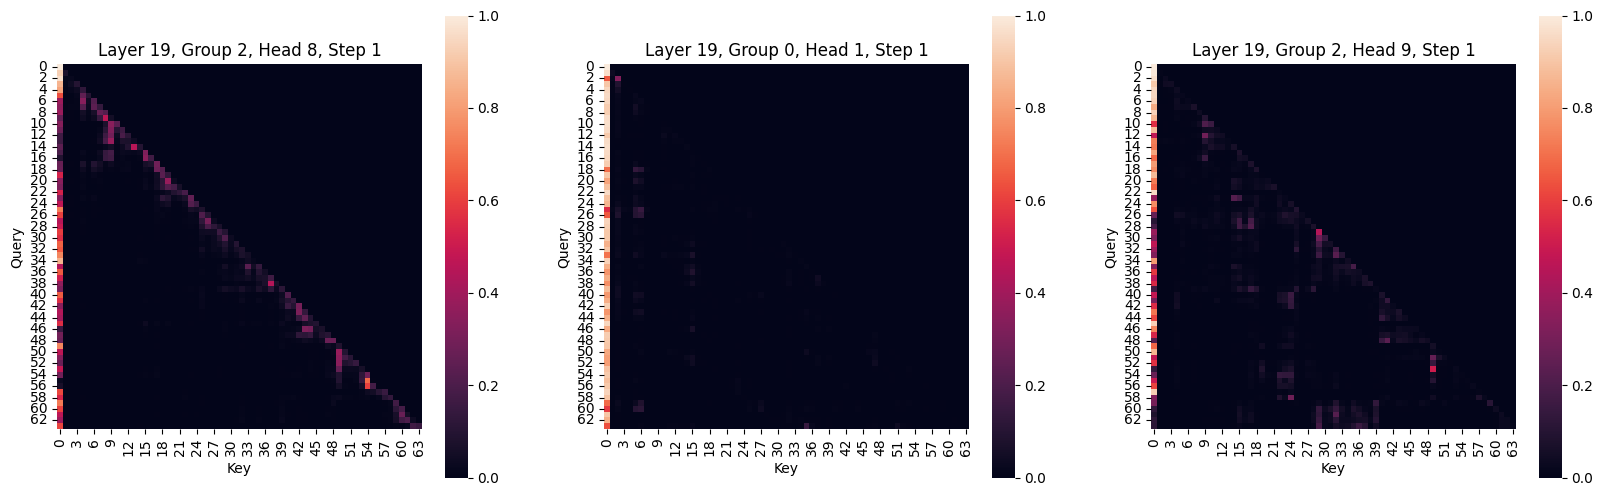

In [5]:
import random

# 设置随机层与Heads
layer = random.randint(0, 31)
heads = random.sample(range(31), 3)

print(f"随机选择的 Layer: {layer}")
print(f"随机选择的 Heads: {heads}")

from matplotlib import pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
for i, head in enumerate(heads):
    # 计算 group 和 kv_head
    group = head // 4
    q_head = head % 4  # 32 heads, 8 kv_heads per group
    print(f"Head {head}")
    gqa_heatmap(layer=layer, group=group, q_head=q_head, step=1, end=64, ax=ax[i])
fig.show()

In [2]:
from ipywidgets import interact, fixed
interact(gqa_heatmap, layer=(0, 31, 1), group=(0, 3, 1), kv_head=(0, 7, 1), step=(1, 128, 1), path=fixed("./results"), grp_size=fixed(4), end=(32, 138), ax=fixed(None))

interactive(children=(IntSlider(value=0, description='layer', max=31), IntSlider(value=0, description='group',…

<function __main__.gqa_heatmap(layer=0, group=0, q_head=0, step=1, grp_size=4, path='./results', end=-1, ax=None)>

## Decoding 的注意力模式有何不同？

将不同解码步的attention score张量拼接到一起，填充padding直到对齐到最宽的那一个。

maxlen: 156


<Axes: >

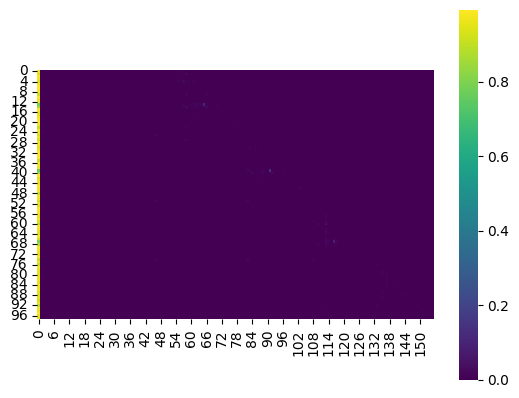

In [18]:
from llm_study.utils import feature as ft

layer = 2
genlen = 100
head = 1

last_query = ft.load("./results", layer=layer, step=genlen, type="attn_weights") # (batch, head, q, k)
maxlen = last_query.shape[-1]
print(f"maxlen: {maxlen}")

attn_list = []
for step in range(2, genlen):
    attn = ft.load("./results", layer=layer, step=step, type="attn_weights")
    attn_list.append(attn)

import torch
import torch.nn.functional as F

padded_attn_list = [F.pad(attn, (0, maxlen - attn.shape[-1]), value=0) for attn in attn_list]
decode_attn = torch.cat(padded_attn_list, dim=-2) # (bsz, head, step, token)

import seaborn as sns

sns.heatmap(decode_attn[0, head, :, :], square=True, cbar=True, cmap='viridis')